In [1]:
# LVDT_simulation/notebook/curve_fit_test.ipynb
import sys
sys.path.append('..')
import numpy as np
import matplotlib.pyplot as plt
from core import data_handler
from scipy.optimize import curve_fit

In [ ]:
filename = "../simulation/data/demo/vc_result.h5"

data_dict = data_handler.load_data(filename)
config_data = data_handler.get_config_data(data_dict)
vc_data = data_handler.get_vc_data(data_dict)

position = vc_data['position']
Lower_Coil_force = vc_data['Lower_Coil']['force']
Upper_Coil_force = vc_data['Upper_Coil']['force']
tot_force = np.abs(Lower_Coil_force + Upper_Coil_force)


In [3]:
def quadratic(x, a, b, c):
    return a*x**2 + b*x + c
params, covariance = curve_fit(quadratic, position, tot_force)
fitted_force_constant = quadratic(position, *params)
max_fitted_force_constant= np.max(fitted_force_constant)
force_error = max_fitted_force_constant - fitted_force_constant
force_error_percent = (force_error / max_fitted_force_constant) * 100
max_force_error_percent = np.max(force_error_percent)

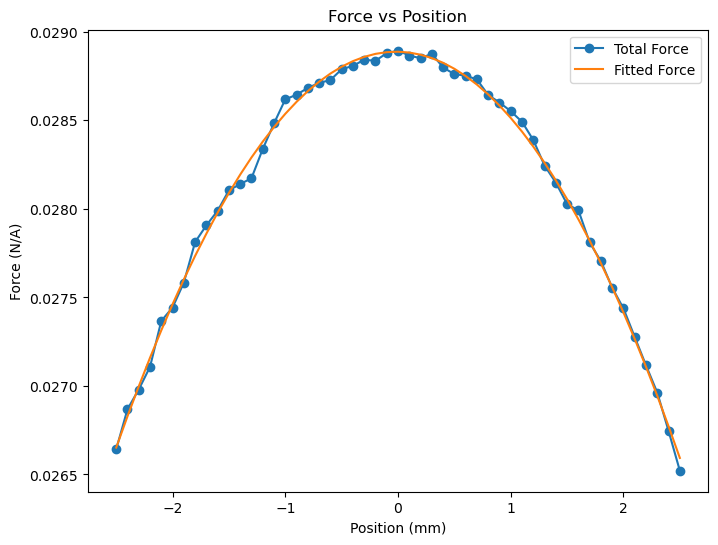

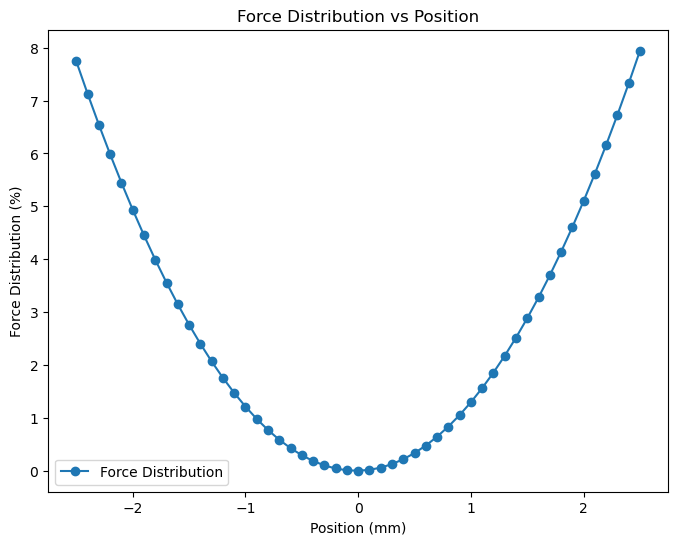

In [4]:

plt.figure(figsize=(8,6))
plt.plot(position, tot_force, marker = "o", label= 'Total Force')
plt.plot(position, fitted_force_constant, label='Fitted Force')
plt.xlabel('Position (mm)')
plt.ylabel('Force (N/A)')
plt.title('Force vs Position')
plt.legend()
plt.show()


plt.figure(figsize=(8,6))
plt.plot(position, force_error_percent, marker = "o", label= 'Force Distribution')
plt.xlabel('Position (mm)')
plt.ylabel('Force Distribution (%)')
plt.title('Force Distribution vs Position')
plt.legend()
plt.show()